"""03_Health_Evaluation.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/REPLACE_WITH_YOUR_COPY

# 🌿 VedaVision — Module 2
# Notebook 03 — Health Evaluation Pipeline (Handcrafted Mathematical Rules)
### HSV Conversion → Leaf Isolation → Colour Masks → Noise Cleanup → Health % → Export

---
**Input**  : `dataset/health_raw/species_name/top/*.jpg` and `species_name/bottom/*.jpg`
             (same physical-leaf-ID naming convention as Module 2 species-ID data:
             `top (1)_pre.jpg`, `bottom (1)_pre.jpg`, i.e. the number in parentheses
             identifies the physical leaf so top+bottom can be paired.)

**Output** : `dataset/health_results/leaf_health_report.csv`
             `dataset/health_results/health_rules.py`  <-- the deployable module
             (NOT a .pkl — there is no trained model here, only deterministic
             colour-threshold logic, so a plain importable .py function is the
             correct artifact, same as `preprocessing.py` / `feature_extraction.py`)

---
### Pipeline (matches your flowchart exactly):
```
Raw Image
    |
1.  Convert to HSV
    |
2.  Separate Background (Leaf Isolation) -- reuses the same bridge-break
    segment_leaf() approach as 02_Preprocessing.ipynb, so leaf boundaries
    are found the same trustworthy way in both notebooks
    |
3.  Extract Colour Masks (Healthy vs Damaged)
    -> healthy (green), yellowing (chlorosis), brown/necrotic, black/dead
       spots, pale/fungal patches -- all handcrafted HSV rules, no model
    |
4.  Clean Noise (Morphological Operations)
    -> small-blob removal + morphological open on each damage mask so a
       few stray pixels (JPEG artifact, vein highlight) can't masquerade
       as "damage"
    |
5.  Compute Direct Pixel Math
    Health % = (Healthy Pixels / Total Leaf Pixels) * 100
    |
6.  Combine Top + Bottom (physical leaf level)
    -> area-weighted average of the two views' health %, so the view with
       more visible leaf surface counts proportionally more
    |
7.  Save Logic as Python Function (no .pkl!)
    -> `health_rules.py`, drop-in next to preprocessing.py / feature_extraction.py
    |
8.  Import Function in App & Return %
```
---
### Why area-weighted, not a plain average, for top+bottom

A simple `(top_health + bottom_health) / 2` silently assumes both photos
show the same amount of leaf surface. In practice a slightly different
crop, angle, or camera distance means the two views rarely have identical
leaf pixel counts. Weighting by each view's own leaf-pixel area means a
view that captured more genuine leaf tissue contributes proportionally
more to the final score — the same logic you already apply in
02_Preprocessing (`keep_largest_contours`'s absolute-area floor) to avoid
letting a smaller region distort a decision. The unweighted mean is kept
in Cell 10 as a commented-out alternative in case you want to compare
both for your thesis writeup.

---
### Why these are RULES, not a trained model — and why that means no .pkl

Every threshold below (`HEALTHY_HUE_RANGE`, `NECROTIC_V_MAX`, etc.) is a
fixed number you set once, not a weight learned from data. There is
nothing to serialize with `joblib`/`pickle` — the entire "model" IS the
Python function. Exporting a `.pkl` here would just be pickling a
function object for no benefit, and would also break the moment you
import it in a different Python/OpenCV version. A plain `.py` module
(Cell 14 below) is both correct and simpler to deploy.

---
### Run Order:
```
01_Augmentation.ipynb -> 02_Preprocessing.ipynb -> 03_Health_Evaluation.ipynb
```
(Health evaluation can run on its own raw health-labelled dataset, separate
from the species-ID dataset — per your project's plan for a distinct
health dataset/feature namespace.)
---


In [ ]:
!pip install opencv-python-headless scikit-image matplotlib numpy tqdm pandas -q
print('✅ Libraries installed!')

"""## Cell 2 — Import Libraries"""

In [1]:
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import gc
from glob import glob
from tqdm import tqdm

"""## Cell 3 — Mount Google Drive & Configure Paths
**Only change things in this cell — everything else runs automatically.**
"""


In [2]:
HEALTH_RAW_PATH    = 'C:/Users/User/Documents/UOM/L4S2/Research/health/Health_Raw'
HEALTH_RESULTS_PATH = 'C:/Users/User/Documents/UOM/L4S2/Research/health_results'
LOGS_PATH           = 'C:/Users/User/Documents/UOM/L4S2/Research/logs'

VIEWS     = ['top', 'bottom']
WORK_SIZE = (512, 512)

# --------------------------------------------------------------------------
# Handcrafted colour-rule thresholds (OpenCV HSV: H 0-179, S/V 0-255)
# Tune these the same iterative way you tuned segment_leaf()'s parameters
# in 02_Preprocessing.ipynb -- print the QC pass rate (Cell 11) after any
# change before committing to it.
# --------------------------------------------------------------------------
HEALTHY_HUE_RANGE   = (35, 85)     # green tissue
HEALTHY_MIN_SAT     = 40
HEALTHY_MIN_VAL     = 40

YELLOW_HUE_RANGE    = (20, 35)     # chlorosis / early stress
YELLOW_MIN_SAT      = 40

BROWN_HUE_RANGE     = (5, 25)      # necrotic brown tissue
BROWN_MAX_VAL        = 150         # darker than yellow -> distinguishes brown from yellow

BLACK_MAX_VAL        = 60          # dead/blackened spots, any hue

PALE_MAX_SAT         = 30          # fungal / bleached patches
PALE_MIN_VAL         = 200

MIN_DAMAGE_BLOB_AREA = 15          # px, post-cleanup noise floor

print('✅ Config set!')
print(f'📁 Input  : {HEALTH_RAW_PATH}')
print(f'📁 Output : {HEALTH_RESULTS_PATH}')

os.makedirs(HEALTH_RESULTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

species_list = sorted([
    d for d in os.listdir(HEALTH_RAW_PATH)
    if os.path.isdir(os.path.join(HEALTH_RAW_PATH, d))
    and not d.startswith('.')
]) if os.path.exists(HEALTH_RAW_PATH) else []

print(f'🌿 Species: {species_list}')

✅ Config set!
📁 Input  : C:/Users/User/Documents/UOM/L4S2/Research/health/Health_Raw
📁 Output : C:/Users/User/Documents/UOM/L4S2/Research/health_results
🌿 Species: ['Diya_Na', 'Gammiris', 'Ingini', 'Iriveriya', 'Kapparawalliya', 'Kora_Kaha', 'Kuringchan', 'Kurundu', 'Masbadda', 'Na', 'Rathu_Koboleela', 'Sudu_Koboleela', 'Wali_Kaha']


 Cell 4 — Helper Functions

In [3]:
def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def get_images(base_path, species, view):
    return (
        glob(os.path.join(base_path, species, view, '*.jpg'))  +
        glob(os.path.join(base_path, species, view, '*.jpeg')) +
        glob(os.path.join(base_path, species, view, '*.png'))
    )


def resize_with_padding(image, target_size, pad_value=255):
    """Resize preserving aspect ratio, pad the rest with white.
    (Identical to 02_Preprocessing.ipynb -- keeps leaf-shape features
    from being distorted before health analysis, same reasoning as there.)
    """
    h, w = image.shape[:2]
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h))
    canvas = np.full((target_h, target_w, 3), pad_value, dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def extract_leaf_id(filename):
    """
    Extracts the physical leaf ID from filenames such as:
        top (1)_pre.jpg, bottom (1)_pre.jpg
    so a top image and bottom image of the SAME physical leaf can be
    paired for the combined full-leaf health score in Cell 10.
    (Same convention/logic as the train/test split script you're
    already using for Module 2 species-ID.)
    """
    match = re.search(r'\((\d+)\)', filename)
    if match is None:
        raise ValueError(f'Could not find a leaf ID "(n)" in filename: {filename}')
    return match.group(1)


def group_by_leaf(image_paths):
    groups = {}
    for path in image_paths:
        leaf_id = extract_leaf_id(os.path.basename(path))
        groups.setdefault(leaf_id, []).append(path)
    return groups


print('✅ Helper functions defined!')

✅ Helper functions defined!


"""## Cell 5 — Leaf Isolation (reused from 02_Preprocessing.ipynb)

Duplicated here rather than imported so this notebook stays fully
self-contained per your notebook-per-stage workflow. If you later build
the shared `preprocessing/shared/` utilities layer, replace this cell
with an import instead of a copy.
"""


In [4]:
def get_border_connected_background(candidate_bg, bridge_break_px=7):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_break_px, bridge_break_px))
    eroded_bg = cv2.erode(candidate_bg, kernel)
    h, w = eroded_bg.shape
    padded = cv2.copyMakeBorder(eroded_bg, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=255)
    flood_seed = np.zeros((h + 4, w + 4), np.uint8)
    filled = padded.copy()
    cv2.floodFill(filled, flood_seed, (0, 0), 128)
    border_bg = ((filled == 128).astype(np.uint8) * 255)[1:-1, 1:-1]
    border_bg = cv2.dilate(border_bg, kernel)
    border_bg = cv2.bitwise_and(border_bg, candidate_bg)
    return border_bg


def remove_small_blobs(mask, min_area=100):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 255
    return clean


def keep_largest_contours(mask, keep_ratio=0.05, min_absolute_area=1500):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask
    areas = [cv2.contourArea(c) for c in contours]
    largest_area = max(areas)
    clean = np.zeros_like(mask)
    for c, a in zip(contours, areas):
        if a >= largest_area * keep_ratio or a >= min_absolute_area:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean


def segment_leaf(image,
                 dark_v_thresh=90,
                 min_shadow_area=200,
                 max_artifact_area=150,
                 bridge_break_px=7,
                 morph_kernel_size=3,
                 min_blob_area=100,
                 otsu_relax_factor=0.8):
    """Same bridge-break segmentation as 02_Preprocessing.ipynb. Returns a
    binary mask: 255 = leaf, 0 = background/shadow."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    otsu_thresh, _ = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    relaxed_thresh = otsu_thresh * otsu_relax_factor
    _, candidate_leaf = cv2.threshold(s, relaxed_thresh, 255, cv2.THRESH_BINARY)
    candidate_bg = cv2.bitwise_not(candidate_leaf)

    border_bg = get_border_connected_background(candidate_bg, bridge_break_px)
    enclosed = cv2.bitwise_and(candidate_bg, cv2.bitwise_not(border_bg))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(enclosed, connectivity=8)
    dark_enclosed = np.zeros_like(enclosed)
    undecided = []

    for label in range(1, num_labels):
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < min_shadow_area:
            undecided.append(label)
            continue
        if np.median(v[comp]) < dark_v_thresh:
            dark_enclosed[comp] = 255
        else:
            undecided.append(label)

    kernel_adj = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    dilated_dark = cv2.dilate(dark_enclosed, kernel_adj, iterations=1)

    for label in undecided:
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < max_artifact_area and np.any(dilated_dark[comp]):
            dark_enclosed[comp] = 255

    background_mask = cv2.bitwise_or(border_bg, dark_enclosed)
    leaf_mask = cv2.bitwise_not(background_mask)

    leaf_mask = remove_small_blobs(leaf_mask, min_area=min_blob_area)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    leaf_mask = keep_largest_contours(leaf_mask)
    return leaf_mask


Cell 6 — Health Classification Rules (Handcrafted HSV Colour Masks)

In [5]:
def build_health_masks(image_bgr, leaf_mask):
    """
    Classifies every LEAF pixel (background already excluded via leaf_mask)
    into exactly one of: healthy, yellowing, brown/necrotic, black/dead,
    pale/fungal, or 'other damage' (leaf pixels that don't clearly match
    any rule -- counted as damaged by exclusion, since only genuinely
    green tissue should count as healthy).

    Returns a dict of binary masks, each already restricted to leaf_mask.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    leaf_bool = leaf_mask > 0

    def to_mask(bool_arr):
        return (bool_arr & leaf_bool).astype(np.uint8) * 255

    healthy = to_mask(
        (h >= HEALTHY_HUE_RANGE[0]) & (h <= HEALTHY_HUE_RANGE[1]) &
        (s >= HEALTHY_MIN_SAT) & (v >= HEALTHY_MIN_VAL)
    )

    yellow = to_mask(
        (h >= YELLOW_HUE_RANGE[0]) & (h <= YELLOW_HUE_RANGE[1]) &
        (s >= YELLOW_MIN_SAT)
    )

    brown = to_mask(
        (h >= BROWN_HUE_RANGE[0]) & (h <= BROWN_HUE_RANGE[1]) &
        (v <= BROWN_MAX_VAL)
    )

    black = to_mask(v <= BLACK_MAX_VAL)

    pale = to_mask((s <= PALE_MAX_SAT) & (v >= PALE_MIN_VAL))

    # Resolve overlaps: healthy always wins ties over damage categories
    # (a pixel classified healthy is removed from every damage mask),
    # then damage categories are made mutually exclusive in priority
    # order black > brown > pale > yellow, so a very dark brown spot is
    # counted once, as black, not double-counted across masks.
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(healthy))
    brown  = cv2.bitwise_and(brown,  cv2.bitwise_not(healthy))
    black  = cv2.bitwise_and(black,  cv2.bitwise_not(healthy))
    pale   = cv2.bitwise_and(pale,   cv2.bitwise_not(healthy))

    brown  = cv2.bitwise_and(brown,  cv2.bitwise_not(black))
    pale   = cv2.bitwise_and(pale,   cv2.bitwise_not(black))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(black))

    pale   = cv2.bitwise_and(pale,   cv2.bitwise_not(brown))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(brown))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(pale))

    return {
        'healthy': healthy,
        'yellow': yellow,
        'brown': brown,
        'black': black,
        'pale': pale,
    }


print('✅ Health classification rules defined!')


✅ Health classification rules defined!


Cell 7 — Noise Cleanup for Damage Masks

In [6]:
def clean_health_masks(masks, min_area=MIN_DAMAGE_BLOB_AREA):
    """
    Morphological open + small-blob removal on every mask. Without this,
    a single stray pixel from a specular highlight or JPEG compression
    artifact can register as a 'damage' blob and nudge the health % for
    no real reason -- same rationale as `remove_small_blobs` in
    02_Preprocessing.ipynb, applied here per damage category instead of
    once on the whole leaf mask.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = {}
    for name, mask in masks.items():
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        cleaned[name] = remove_small_blobs(opened, min_area=min_area)
    return cleaned
    print('✅ Noise cleanup ready!')

Cell 8 — Full Health Pipeline for a Single View (Direct Pixel Math)

In [7]:
def evaluate_single_view_health(image_bgr):
    """
    Runs the full rule-based pipeline on ONE image (one leaf view: top OR
    bottom) and returns a health report dict. This is the core function
    that gets exported to health_rules.py in Cell 14.

    Health % = (Healthy Pixels / Total Leaf Pixels) * 100
    """
    img = resize_with_padding(image_bgr, WORK_SIZE)
    leaf_mask = segment_leaf(img)

    total_leaf_px = int(cv2.countNonZero(leaf_mask))
    if total_leaf_px == 0:
        return None

    masks = build_health_masks(img, leaf_mask)
    masks = clean_health_masks(masks)

    counts = {name: int(cv2.countNonZero(m)) for name, m in masks.items()}
    damage_px = counts['yellow'] + counts['brown'] + counts['black'] + counts['pale']

    # Any leaf pixel not claimed by a specific rule still counts as
    # damaged by exclusion -- only pixels that pass the healthy-green
    # test are ever counted as healthy.
    unclassified_px = max(0, total_leaf_px - counts['healthy'] - damage_px)

    health_pct = round(counts['healthy'] / total_leaf_px * 100, 2)

    return {
        'leaf_area_px': total_leaf_px,
        'healthy_pct': health_pct,
        'yellow_pct': round(counts['yellow'] / total_leaf_px * 100, 2),
        'brown_pct': round(counts['brown'] / total_leaf_px * 100, 2),
        'black_pct': round(counts['black'] / total_leaf_px * 100, 2),
        'pale_pct': round(counts['pale'] / total_leaf_px * 100, 2),
        'unclassified_pct': round(unclassified_px / total_leaf_px * 100, 2),
        'masks': masks,          # keep for visualization in Cell 9; drop before exporting to app
        'leaf_mask': leaf_mask,  # same
        'working_image': img,    # same
    }


print('✅ evaluate_single_view_health() ready!')

✅ evaluate_single_view_health() ready!


Cell 9 — Test on ONE Image & See Every Step

C:\Users\User\AppData\Local\Temp\ipykernel_6852\1375992677.py:41: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_6852\1375992677.py:42: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/03_health_eval_steps.png', bbox_inches='tight', dpi=120)
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


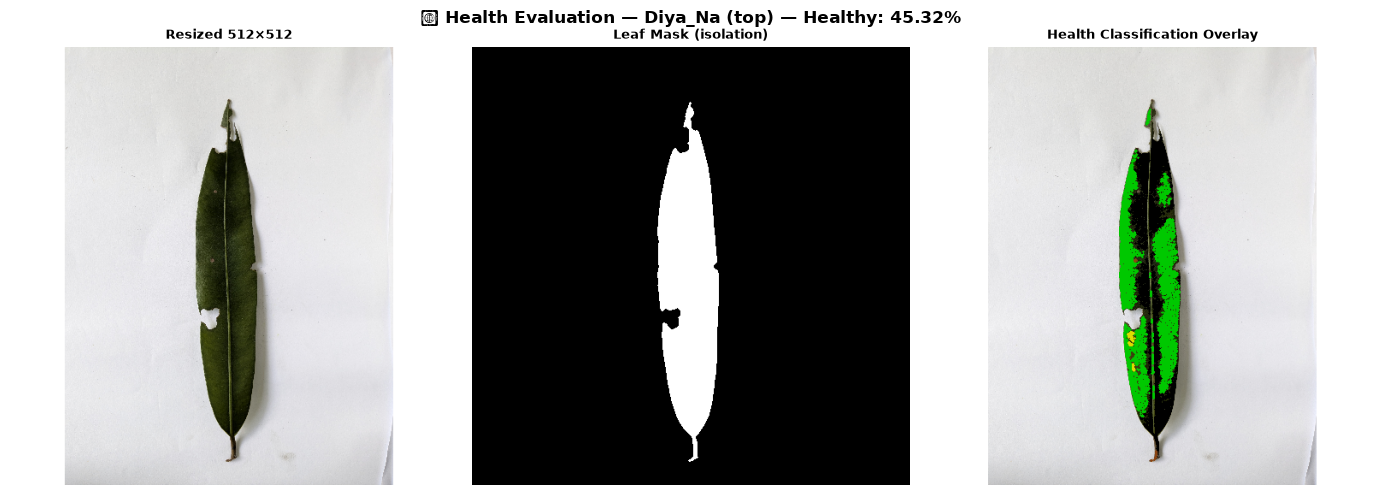

  Healthy      : 45.32%
  Yellowing    : 0.74%
  Brown/necrotic: 0.29%
  Black/dead   : 33.43%
  Pale/fungal  : 0.0%
  Unclassified : 20.23%

👉 Green tissue miscounted as damage?  Widen HEALTHY_HUE_RANGE or lower HEALTHY_MIN_SAT (Cell 3)
👉 Obvious brown spots missed?          Raise BROWN_MAX_VAL or widen BROWN_HUE_RANGE (Cell 3)
👉 Speckle noise inflating damage %?     Raise MIN_DAMAGE_BLOB_AREA (Cell 3)


In [8]:
sample_species = species_list[0] if species_list else None

if sample_species is None:
    print('⚠️  No species folders found under HEALTH_RAW_PATH yet — add data first.')
else:
    sample_view = VIEWS[0]
    sample_imgs = get_images(HEALTH_RAW_PATH, sample_species, sample_view)

    if not sample_imgs:
        print(f'⚠️  No images found in {HEALTH_RAW_PATH}/{sample_species}/{sample_view}/')
    else:
        sample_bgr = cv2.imread(random.choice(sample_imgs))
        report = evaluate_single_view_health(sample_bgr)

        if report is None:
            print('⚠️  Leaf mask came back empty for this image — check segmentation params.')
        else:
            overlay = report['working_image'].copy()
            overlay[report['masks']['healthy'] > 0] = (0, 200, 0)      # green
            overlay[report['masks']['yellow'] > 0]  = (0, 220, 220)    # yellow
            overlay[report['masks']['brown'] > 0]   = (19, 69, 139)    # brown
            overlay[report['masks']['black'] > 0]   = (0, 0, 0)        # black
            overlay[report['masks']['pale'] > 0]    = (200, 200, 255)  # pale pink

            steps = [
                (bgr2rgb(report['working_image']), 'Resized 512×512'),
                (report['leaf_mask'], 'Leaf Mask (isolation)'),
                (bgr2rgb(overlay), 'Health Classification Overlay'),
            ]

            fig, axes = plt.subplots(1, len(steps), figsize=(14, 5))
            fig.suptitle(
                f"🌿 Health Evaluation — {sample_species} ({sample_view}) — "
                f"Healthy: {report['healthy_pct']}%",
                fontsize=12, fontweight='bold'
            )
            for ax, (img_step, title) in zip(axes, steps):
                ax.imshow(img_step, cmap='gray' if len(img_step.shape) == 2 else None)
                ax.set_title(title, fontsize=9, fontweight='bold')
                ax.axis('off')
            plt.tight_layout()
            plt.savefig(f'{LOGS_PATH}/03_health_eval_steps.png', bbox_inches='tight', dpi=120)
            plt.show()

            print(f"  Healthy      : {report['healthy_pct']}%")
            print(f"  Yellowing    : {report['yellow_pct']}%")
            print(f"  Brown/necrotic: {report['brown_pct']}%")
            print(f"  Black/dead   : {report['black_pct']}%")
            print(f"  Pale/fungal  : {report['pale_pct']}%")
            print(f"  Unclassified : {report['unclassified_pct']}%")
            print()
            print('👉 Green tissue miscounted as damage?  Widen HEALTHY_HUE_RANGE or lower HEALTHY_MIN_SAT (Cell 3)')
            print('👉 Obvious brown spots missed?          Raise BROWN_MAX_VAL or widen BROWN_HUE_RANGE (Cell 3)')
            print('👉 Speckle noise inflating damage %?     Raise MIN_DAMAGE_BLOB_AREA (Cell 3)')

Cell 10 — Combine Top + Bottom Views (Full-Leaf Health Score)

In [9]:
def evaluate_full_leaf_health(top_bgr, bottom_bgr):
    """
    Combines a physical leaf's top and bottom view scores into ONE
    full-leaf health %, area-weighted by each view's own leaf pixel
    count (see the note at the top of this notebook for why this beats
    a plain average).

    If only one view is available (e.g. a torn/missing photo), falls
    back to that single view's score rather than failing outright.
    """
    top_report = evaluate_single_view_health(top_bgr) if top_bgr is not None else None
    bottom_report = evaluate_single_view_health(bottom_bgr) if bottom_bgr is not None else None

    if top_report is None and bottom_report is None:
        return None

    if top_report is None:
        combined_pct = bottom_report['healthy_pct']
    elif bottom_report is None:
        combined_pct = top_report['healthy_pct']
    else:
        top_area = top_report['leaf_area_px']
        bottom_area = bottom_report['leaf_area_px']
        combined_pct = round(
            (top_report['healthy_pct'] * top_area +
             bottom_report['healthy_pct'] * bottom_area) /
            (top_area + bottom_area),
            2
        )
        # --- Unweighted alternative, for comparison in your thesis writeup ---
        # combined_pct = round((top_report['healthy_pct'] + bottom_report['healthy_pct']) / 2, 2)

    return {
        'top_healthy_pct': top_report['healthy_pct'] if top_report else None,
        'bottom_healthy_pct': bottom_report['healthy_pct'] if bottom_report else None,
        'top_leaf_area_px': top_report['leaf_area_px'] if top_report else None,
        'bottom_leaf_area_px': bottom_report['leaf_area_px'] if bottom_report else None,
        'combined_healthy_pct': combined_pct,
    }


print('✅ evaluate_full_leaf_health() ready!')


✅ evaluate_full_leaf_health() ready!


"""## Cell 11 — Quality Control
Samples 5 physical leaves per species before running the full dataset.
"""

In [10]:
print('🔍 QUALITY CONTROL — Sampling 5 physical leaves per species')
print('=' * 62)

qc_rows = []
for species in species_list:
    leaf_ids_per_view = {}
    for view in VIEWS:
        imgs = get_images(HEALTH_RAW_PATH, species, view)
        leaf_ids_per_view[view] = group_by_leaf(imgs)

    common_ids = sorted(set(leaf_ids_per_view['top']) & set(leaf_ids_per_view['bottom']))
    if not common_ids:
        print(f'  ⚠️  No paired top+bottom leaves found: {species}')
        continue

    for leaf_id in common_ids[:5]:
        top_path = leaf_ids_per_view['top'][leaf_id][0]
        bottom_path = leaf_ids_per_view['bottom'][leaf_id][0]
        top_img = cv2.imread(top_path)
        bottom_img = cv2.imread(bottom_path)

        result = evaluate_full_leaf_health(top_img, bottom_img)
        if result is None:
            qc_rows.append({'species': species, 'leaf_id': leaf_id, 'status': 'FAIL'})
            continue

        qc_rows.append({
            'species': species, 'leaf_id': leaf_id, 'status': 'PASS',
            'top_pct': result['top_healthy_pct'],
            'bottom_pct': result['bottom_healthy_pct'],
            'combined_pct': result['combined_healthy_pct'],
        })

qc_df = pd.DataFrame(qc_rows)
if len(qc_df):
    pass_rate = (qc_df.status == 'PASS').mean() * 100
    print(f'\n  Total sampled : {len(qc_df)}')
    print(f'  Pass rate     : {pass_rate:.1f}%')
    print(qc_df.to_string(index=False))
    print('\n  ✅ QC PASSED — safe to run Cell 12!' if pass_rate >= 90 else '\n  ⚠️  QC issues found — review FAIL rows above.')
else:
    print('  ⚠️  No data to QC yet.')


🔍 QUALITY CONTROL — Sampling 5 physical leaves per species
  ⚠️  No paired top+bottom leaves found: Diya_Na


ValueError: Could not find a leaf ID "(n)" in filename: PXL_20260714_061759965.jpg

In [ ]:
""## Cell 12 — Run on Full Dataset -> CSV
⚠️ Only run after Cell 11 QC passes (≥90%)
"""

print('🔄 Starting health evaluation on full dataset...')
print('=' * 65)

results = []

for species in species_list:
    leaf_ids_per_view = {}
    for view in VIEWS:
        imgs = get_images(HEALTH_RAW_PATH, species, view)
        leaf_ids_per_view[view] = group_by_leaf(imgs)

    common_ids = sorted(set(leaf_ids_per_view['top']) & set(leaf_ids_per_view['bottom']))

    for leaf_id in tqdm(common_ids, desc=f'  {species}'):
        top_path = leaf_ids_per_view['top'][leaf_id][0]
        bottom_path = leaf_ids_per_view['bottom'][leaf_id][0]

        top_img = cv2.imread(top_path)
        bottom_img = cv2.imread(bottom_path)

        result = evaluate_full_leaf_health(top_img, bottom_img)
        if result is None:
            continue

        results.append({
            'species': species,
            'leaf_id': leaf_id,
            'top_healthy_pct': result['top_healthy_pct'],
            'bottom_healthy_pct': result['bottom_healthy_pct'],
            'combined_healthy_pct': result['combined_healthy_pct'],
        })

        del top_img, bottom_img
    gc.collect()

results_df = pd.DataFrame(results)
csv_path = os.path.join(HEALTH_RESULTS_PATH, 'leaf_health_report.csv')
results_df.to_csv(csv_path, index=False)

print('=' * 65)
print(f'✅ Done! {len(results_df)} physical leaves evaluated.')
print(f'📄 Saved: {csv_path}')

Cell 13 — Preview Results

In [ ]:
if len(results_df):
    print('📊 Average combined health % by species:')
    print(results_df.groupby('species')['combined_healthy_pct'].mean().round(1).to_string())
else:
    print('⚠️  No results to preview yet.')


Cell 14 — Export Standalone Rule Module (No .pkl needed!)

This writes `health_rules.py` containing everything the FastAPI backend
needs, with no dependency on notebook-only variables. Drop it into
`backend/app/module2_single_leaves/` next to `preprocessing.py` and
`feature_extraction.py`.

In [ ]:
import cv2
import numpy as np

WORK_SIZE = (512, 512)

HEALTHY_HUE_RANGE = ''' + repr(HEALTHY_HUE_RANGE) + '''
HEALTHY_MIN_SAT = ''' + repr(HEALTHY_MIN_SAT) + '''
HEALTHY_MIN_VAL = ''' + repr(HEALTHY_MIN_VAL) + '''
YELLOW_HUE_RANGE = ''' + repr(YELLOW_HUE_RANGE) + '''
YELLOW_MIN_SAT = ''' + repr(YELLOW_MIN_SAT) + '''
BROWN_HUE_RANGE = ''' + repr(BROWN_HUE_RANGE) + '''
BROWN_MAX_VAL = ''' + repr(BROWN_MAX_VAL) + '''
BLACK_MAX_VAL = ''' + repr(BLACK_MAX_VAL) + '''
PALE_MAX_SAT = ''' + repr(PALE_MAX_SAT) + '''
PALE_MIN_VAL = ''' + repr(PALE_MIN_VAL) + '''
MIN_DAMAGE_BLOB_AREA = ''' + repr(MIN_DAMAGE_BLOB_AREA) + '''


def resize_with_padding(image, target_size, pad_value=255):
    h, w = image.shape[:2]
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h))
    canvas = np.full((target_h, target_w, 3), pad_value, dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def get_border_connected_background(candidate_bg, bridge_break_px=7):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_break_px, bridge_break_px))
    eroded_bg = cv2.erode(candidate_bg, kernel)
    h, w = eroded_bg.shape
    padded = cv2.copyMakeBorder(eroded_bg, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=255)
    flood_seed = np.zeros((h + 4, w + 4), np.uint8)
    filled = padded.copy()
    cv2.floodFill(filled, flood_seed, (0, 0), 128)
    border_bg = ((filled == 128).astype(np.uint8) * 255)[1:-1, 1:-1]
    border_bg = cv2.dilate(border_bg, kernel)
    border_bg = cv2.bitwise_and(border_bg, candidate_bg)
    return border_bg


def remove_small_blobs(mask, min_area=100):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 255
    return clean


def keep_largest_contours(mask, keep_ratio=0.05, min_absolute_area=1500):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask
    areas = [cv2.contourArea(c) for c in contours]
    largest_area = max(areas)
    clean = np.zeros_like(mask)
    for c, a in zip(contours, areas):
        if a >= largest_area * keep_ratio or a >= min_absolute_area:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean


def segment_leaf(image, dark_v_thresh=90, min_shadow_area=200, max_artifact_area=150,
                  bridge_break_px=7, morph_kernel_size=3, min_blob_area=100,
                  otsu_relax_factor=0.8):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    otsu_thresh, _ = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    relaxed_thresh = otsu_thresh * otsu_relax_factor
    _, candidate_leaf = cv2.threshold(s, relaxed_thresh, 255, cv2.THRESH_BINARY)
    candidate_bg = cv2.bitwise_not(candidate_leaf)

    border_bg = get_border_connected_background(candidate_bg, bridge_break_px)
    enclosed = cv2.bitwise_and(candidate_bg, cv2.bitwise_not(border_bg))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(enclosed, connectivity=8)
    dark_enclosed = np.zeros_like(enclosed)
    undecided = []

    for label in range(1, num_labels):
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < min_shadow_area:
            undecided.append(label)
            continue
        if np.median(v[comp]) < dark_v_thresh:
            dark_enclosed[comp] = 255
        else:
            undecided.append(label)

    kernel_adj = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    dilated_dark = cv2.dilate(dark_enclosed, kernel_adj, iterations=1)

    for label in undecided:
        comp = (labels == label)
        area = stats[label, cv2.CC_STAT_AREA]
        if area < max_artifact_area and np.any(dilated_dark[comp]):
            dark_enclosed[comp] = 255

    background_mask = cv2.bitwise_or(border_bg, dark_enclosed)
    leaf_mask = cv2.bitwise_not(background_mask)
    leaf_mask = remove_small_blobs(leaf_mask, min_area=min_blob_area)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    leaf_mask = keep_largest_contours(leaf_mask)
    return leaf_mask


def build_health_masks(image_bgr, leaf_mask):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    leaf_bool = leaf_mask > 0

    def to_mask(bool_arr):
        return (bool_arr & leaf_bool).astype(np.uint8) * 255

    healthy = to_mask((h >= HEALTHY_HUE_RANGE[0]) & (h <= HEALTHY_HUE_RANGE[1]) &
                       (s >= HEALTHY_MIN_SAT) & (v >= HEALTHY_MIN_VAL))
    yellow = to_mask((h >= YELLOW_HUE_RANGE[0]) & (h <= YELLOW_HUE_RANGE[1]) & (s >= YELLOW_MIN_SAT))
    brown = to_mask((h >= BROWN_HUE_RANGE[0]) & (h <= BROWN_HUE_RANGE[1]) & (v <= BROWN_MAX_VAL))
    black = to_mask(v <= BLACK_MAX_VAL)
    pale = to_mask((s <= PALE_MAX_SAT) & (v >= PALE_MIN_VAL))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(healthy))
    brown = cv2.bitwise_and(brown, cv2.bitwise_not(healthy))
    black = cv2.bitwise_and(black, cv2.bitwise_not(healthy))
    pale = cv2.bitwise_and(pale, cv2.bitwise_not(healthy))

    brown = cv2.bitwise_and(brown, cv2.bitwise_not(black))
    pale = cv2.bitwise_and(pale, cv2.bitwise_not(black))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(black))

    pale = cv2.bitwise_and(pale, cv2.bitwise_not(brown))
    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(brown))

    yellow = cv2.bitwise_and(yellow, cv2.bitwise_not(pale))

    return {'healthy': healthy, 'yellow': yellow, 'brown': brown, 'black': black, 'pale': pale}


def clean_health_masks(masks, min_area=MIN_DAMAGE_BLOB_AREA):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = {}
    for name, mask in masks.items():
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        cleaned[name] = remove_small_blobs(opened, min_area=min_area)
    return cleaned


def evaluate_single_view_health(image_bgr):
    """Returns a health report dict for ONE leaf-view image, or None if
    no leaf could be isolated."""
    img = resize_with_padding(image_bgr, WORK_SIZE)
    leaf_mask = segment_leaf(img)

    total_leaf_px = int(cv2.countNonZero(leaf_mask))
    if total_leaf_px == 0:
        return None

    masks = build_health_masks(img, leaf_mask)
    masks = clean_health_masks(masks)

    counts = {name: int(cv2.countNonZero(m)) for name, m in masks.items()}
    damage_px = counts["yellow"] + counts["brown"] + counts["black"] + counts["pale"]
    unclassified_px = max(0, total_leaf_px - counts["healthy"] - damage_px)

    return {
        "leaf_area_px": total_leaf_px,
        "healthy_pct": round(counts["healthy"] / total_leaf_px * 100, 2),
        "yellow_pct": round(counts["yellow"] / total_leaf_px * 100, 2),
        "brown_pct": round(counts["brown"] / total_leaf_px * 100, 2),
        "black_pct": round(counts["black"] / total_leaf_px * 100, 2),
        "pale_pct": round(counts["pale"] / total_leaf_px * 100, 2),
        "unclassified_pct": round(unclassified_px / total_leaf_px * 100, 2),
    }


def evaluate_full_leaf_health(top_bgr, bottom_bgr):
    """
    Combines top + bottom view scores into one full-leaf health %,
    area-weighted by each view's leaf pixel count. Falls back to a
    single view if the other is missing/unreadable.

    Returns None only if BOTH views fail to yield a leaf mask.
    """
    top_report = evaluate_single_view_health(top_bgr) if top_bgr is not None else None
    bottom_report = evaluate_single_view_health(bottom_bgr) if bottom_bgr is not None else None

    if top_report is None and bottom_report is None:
        return None

    if top_report is None:
        combined_pct = bottom_report["healthy_pct"]
    elif bottom_report is None:
        combined_pct = top_report["healthy_pct"]
    else:
        top_area = top_report["leaf_area_px"]
        bottom_area = bottom_report["leaf_area_px"]
        combined_pct = round(
            (top_report["healthy_pct"] * top_area + bottom_report["healthy_pct"] * bottom_area)
            / (top_area + bottom_area),
            2,
        )

    return {
        "top": top_report,
        "bottom": bottom_report,
        "combined_healthy_pct": combined_pct,
    }
'''

module_out_path = os.path.join(HEALTH_RESULTS_PATH, 'health_rules.py')
with open(module_out_path, 'w') as f:
    f.write(health_rules_source)

print(f'✅ Exported: {module_out_path}')
print('   Copy this file into backend/app/module2_single_leaves/ alongside')
print('   preprocessing.py and feature_extraction.py. No .pkl required.')

"""## Cell 15 — Sanity Test the Exported Module

Confirms the freshly-written health_rules.py gives the SAME numbers as
the notebook functions above, before you wire it into FastAPI.
"""

import importlib.util

spec = importlib.util.spec_from_file_location('health_rules', module_out_path)
health_rules = importlib.util.module_from_spec(spec)
spec.loader.exec_module(health_rules)

if sample_species is not None and sample_imgs:
    notebook_result = evaluate_single_view_health(sample_bgr)
    module_result = health_rules.evaluate_single_view_health(sample_bgr)

    if notebook_result and module_result:
        match = notebook_result['healthy_pct'] == module_result['healthy_pct']
        print(f"  Notebook healthy % : {notebook_result['healthy_pct']}")
        print(f"  Module   healthy % : {module_result['healthy_pct']}")
        print('  ✅ MATCH — health_rules.py is ready to deploy!' if match else
              '  ⚠️  MISMATCH — re-run Cell 14 to re-export, then retest.')
else:
    print('⚠️  No sample image available to sanity-check against.')


Cell 16 — Summary

In [ ]:
print('📊 HEALTH EVALUATION SUMMARY')
print('=' * 55)
if len(results_df):
    print(f'  Physical leaves evaluated : {len(results_df)}')
    print(f'  Species covered           : {results_df["species"].nunique()}')
    print(f'  Mean combined health %    : {results_df["combined_healthy_pct"].mean():.1f}%')
else:
    print('  No results yet -- run Cells 11-12 once HEALTH_RAW_PATH has data.')
print('=' * 55)
print(f'📁 CSV    : {os.path.join(HEALTH_RESULTS_PATH, "leaf_health_report.csv")}')
print(f'📁 Module : {os.path.join(HEALTH_RESULTS_PATH, "health_rules.py")}')
print('📋 Next step: copy health_rules.py into backend/app/module2_single_leaves/')
print('             and add a POST /module2/single-leaf/health-check route')
print('             that reads top+bottom UploadFiles and calls')
print('             evaluate_full_leaf_health(top_bgr, bottom_bgr).')
